In [3]:
import numpy as np
import sys
import os
import shutil
import subprocess
import torch
import matplotlib.pyplot as plt

In [ ]:
#Для модели с нуля.
from sklearn.cluster import KMeans
from collections import OrderedDict
import random

Для разметки данных использую labelimg.

In [38]:
# путь к labelImg.py
script_path = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/labelImg/labelImg.py"

In [ ]:

base_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/train/all_images_n_annotations"

images_dir = os.path.join(base_dir, "images")
annotations_dir = os.path.join(base_dir, "annotations")

os.makedirs(images_dir, exist_ok=True)
os.makedirs(annotations_dir, exist_ok=True)

# 1. СНАЧАЛА разложим файлы
for file in os.listdir(base_dir):
    path = os.path.join(base_dir, file)

    if os.path.isdir(path):
        continue

    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        shutil.move(path, os.path.join(images_dir, file))

    elif file.lower().endswith(".xml"):
        shutil.move(path, os.path.join(annotations_dir, file))


# 2. КОПИРУЕМ XML рядом с изображениями
for file in os.listdir(images_dir):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        name = os.path.splitext(file)[0]
        xml_file = name + ".xml"

        src = os.path.join(annotations_dir, xml_file)
        dst = os.path.join(images_dir, xml_file)

        if os.path.exists(src):
            shutil.copy(src, dst)

print("Готово")

Готово


<Popen: returncode: None args: ['python', '/home/svetotch/ML_Itmo/machine_le...>

Image:/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/train/all_images_n_annotations/images/faded_1139.jpg -> Annotation:/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/train/all_images_n_annotations/images/faded_1139.xml
ESC press
Cancel creation.
Image:/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/train/all_images_n_annotations/images/faded_1140.jpg -> Annotation:/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/train/all_images_n_annotations/images/faded_1140.xml
Image:/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/train/all_images_n_annotations/images/faded_1141.jpg -> Annotation:/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/train/all_images_n_annotations/images/faded_1141.xml
Image:/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/train/all_images_n_annotations/images/faded_1142.jpeg -> Annotation:/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/train/all_images_n_annotations/images/faded_1142.xml
Image:/home/

In [ ]:
images_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/train/all_images_n_annotations/images"

In [37]:
subprocess.Popen(["python",script_path,images_dir])

<Popen: returncode: None args: ['python', '/home/svetotch/ML_Itmo/machine_le...>

In [ ]:
import os
import xml.etree.ElementTree as ET

for file in os.listdir(base_dir):
    if not file.endswith(".xml"):
        continue

    path = os.path.join(base_dir, file)
    tree = ET.parse(path)
    root = tree.getroot()

    for p in root.findall("path"):
        root.remove(p)

    tree.write(path, encoding="utf-8", xml_declaration=True)

In [ ]:
print(sys.executable)
print(sys.version)

/home/svetotch/ML_Itmo/machine_learning_hogweeds/venv/bin/python
3.10.20 (main, Mar  3 2026, 09:24:47) [GCC 13.3.0]


In [23]:
images = {os.path.splitext(f)[0] for f in os.listdir("hogweed/train/images")}
xmls = {os.path.splitext(f)[0] for f in os.listdir("hogweed/train/annotations")}

print("missing XML:", images - xmls)
print("extra XML:", xmls - images)

missing XML: {'thickets_1321', 'thickets_2171', 'faded_1627', 'faded_1852', 'thickets_1023', 'thickets_0708', 'thickets_1224', 'thickets_1821', 'thickets_1096', 'thickets_1969', 'thickets_2586', 'thickets_1478', 'faded_1477', 'thickets_1198', 'faded_1389', 'thickets_2058', 'thickets_1078', 'thickets_0473', 'thickets_1440', 'faded_1239', 'thickets_1277', 'thickets_0398', 'thickets_0635', 'thickets_1152', 'thickets_0453', 'faded_1780', 'thickets_0114', 'thickets_2251', 'faded_1723', 'thickets_1226', 'thickets_0507', 'thickets_1377', 'faded_1173', 'faded_1728', 'thickets_0412', 'thickets_1823', 'thickets_1511', 'thickets_2140', 'thickets_1203', 'faded_1601', 'thickets_0992', 'thickets_0757', 'thickets_2090', 'faded_1600', 'thickets_1757', 'faded_1231', 'thickets_1843', 'thickets_2457', 'thickets_0327', 'thickets_1451', 'thickets_2084', 'thickets_2073', 'thickets_0880', 'thickets_1008', 'thickets_0744', 'thickets_0518', 'faded_1826', 'thickets_1089', 'faded_1189', 'thickets_2183', 'thicket

 100% |███████████████| 3190/3190 [4.8s elapsed, 0s remaining, 589.1 samples/s]      



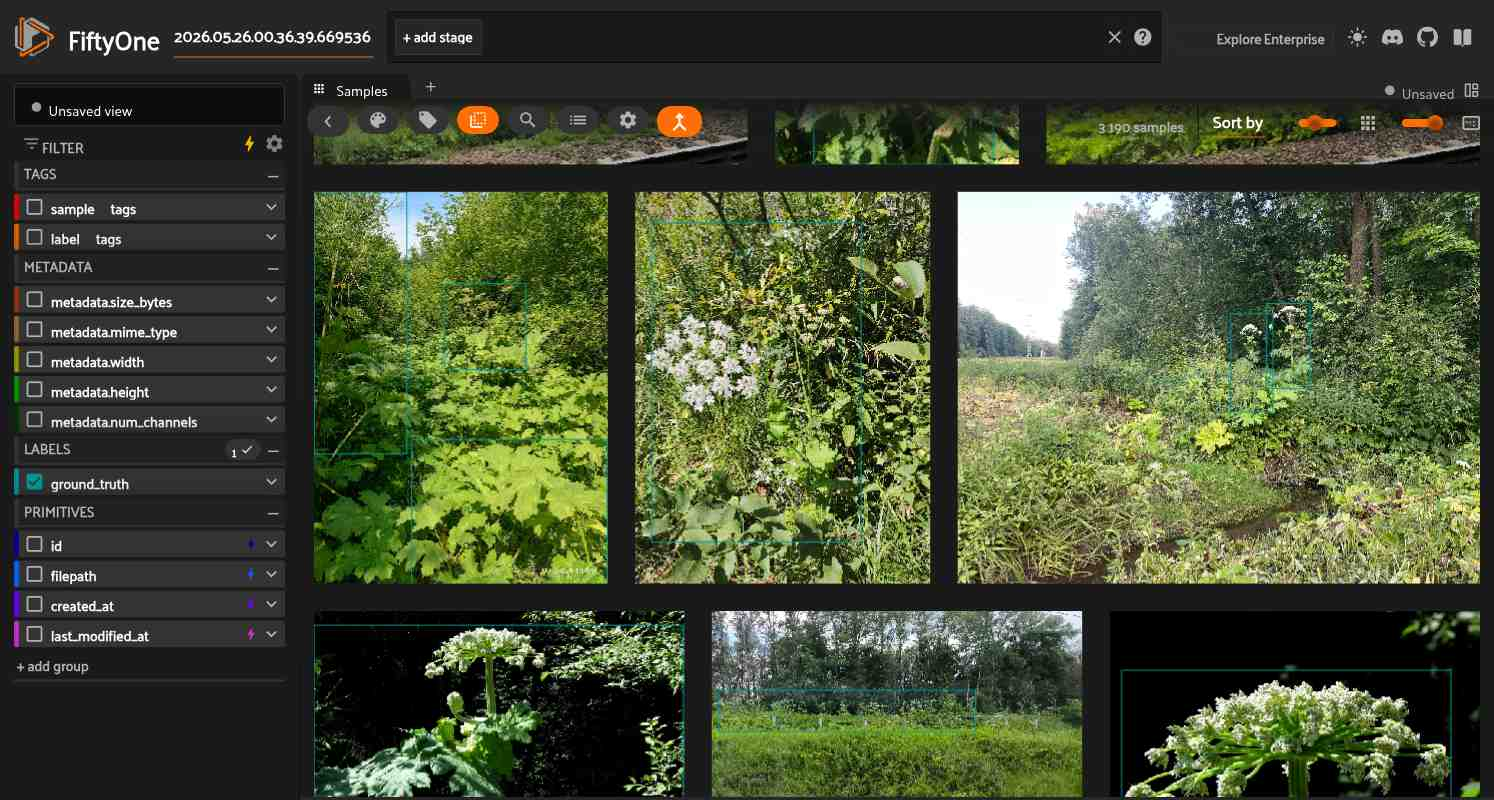

Notebook sessions cannot wait


In [26]:
import fiftyone as fo

dataset = fo.Dataset.from_dir(
    dataset_dir="hogweed",
    dataset_type=fo.types.VOCDetectionDataset,
    data_path="train/images",
    labels_path="train/annotations",
    label_field="ground_truth",
)

session = fo.launch_app(dataset)
session.wait()

In [27]:
dataset.stats()

{'samples_count': 3190,
 'samples_bytes': 3589331,
 'samples_size': '3.4MB',
 'total_bytes': 3589331,
 'total_size': '3.4MB'}


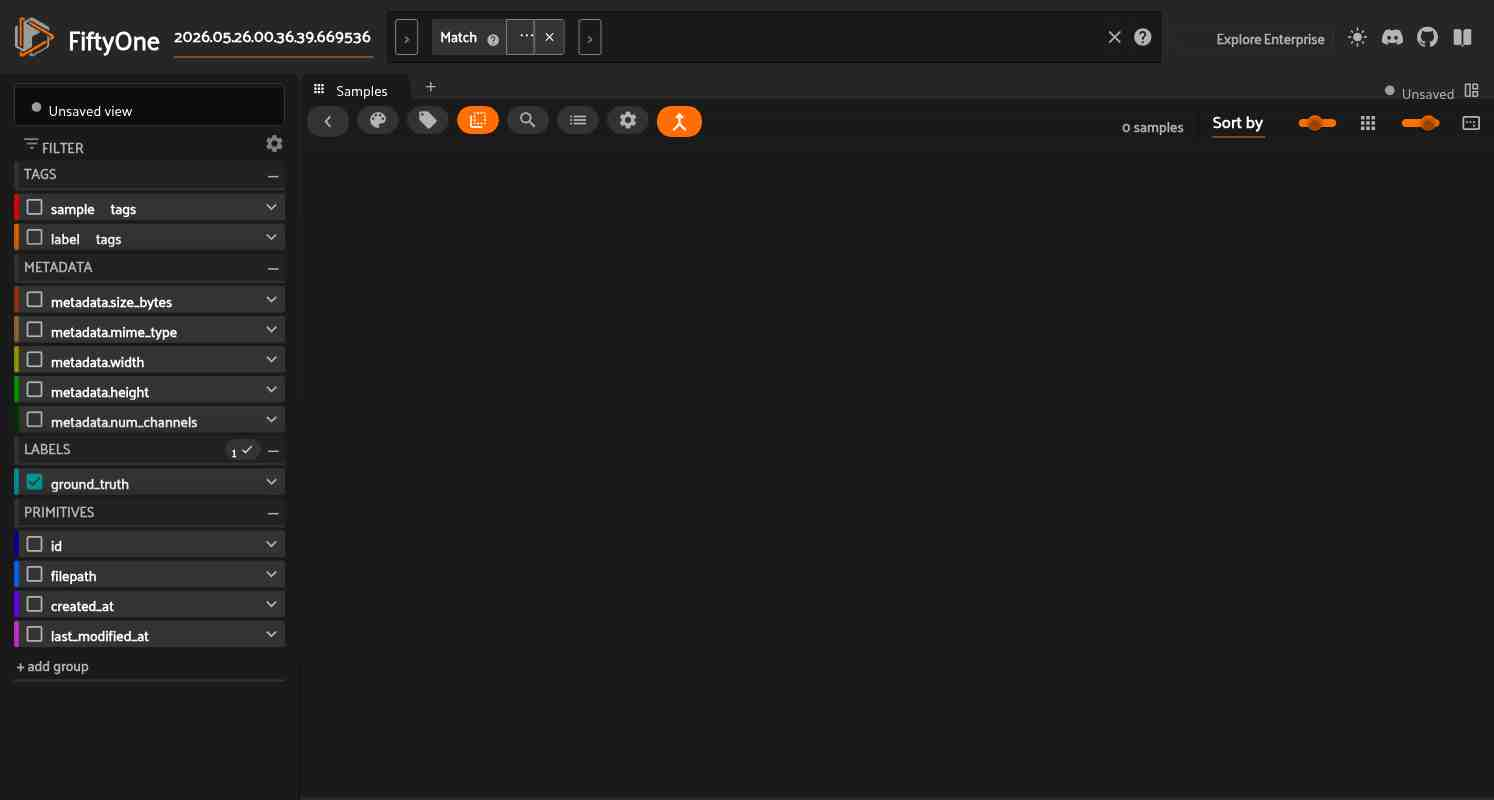

In [ ]:
from fiftyone import ViewField as F

view = dataset.match(F("ground_truth.detections").length() == 0)
session.view = view

In [31]:
dataset.delete_samples(
    dataset.match(F("ground_truth.detections").length() == 0)
)

In [2]:
print(torch.cuda.is_available())

True


In [ ]:
import os
import xml.etree.ElementTree as ET

xml_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/train/annotations_blooming"
img_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/train/images_blooming"

yolo_labels_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo/labels_all"
os.makedirs(yolo_labels_dir, exist_ok=True)

CLASS_MAP = {
    "blooming_sosnovsky": 0,
    "faded_sosnovsky": 1,
    "thickets_sosnovsky":2
}


def convert(size, box):
    dw = 1.0 / size[0]
    dh = 1.0 / size[1]

    x = (box[0] + box[1]) / 2.0 * dw
    y = (box[2] + box[3]) / 2.0 * dh
    w = (box[1] - box[0]) * dw
    h = (box[3] - box[2]) * dh

    return x, y, w, h


for xml_file in os.listdir(xml_dir):

    if not xml_file.endswith(".xml"):
        continue

    tree = ET.parse(os.path.join(xml_dir, xml_file))
    root = tree.getroot()

    size = root.find("size")
    w_img = int(size.find("width").text)
    h_img = int(size.find("height").text)

    lines = []

    for obj in root.findall("object"):
        name = obj.find("name").text

        if name not in CLASS_MAP:
            continue

        class_id = CLASS_MAP[name]

        bnd = obj.find("bndbox")
        xmin = float(bnd.find("xmin").text)
        xmax = float(bnd.find("xmax").text)
        ymin = float(bnd.find("ymin").text)
        ymax = float(bnd.find("ymax").text)

        x, y, w, h = convert((w_img, h_img), (xmin, xmax, ymin, ymax))

        lines.append(f"{class_id} {x} {y} {w} {h}")

    txt_name = xml_file.replace(".xml", ".txt")

    with open(os.path.join(yolo_labels_dir, txt_name), "w") as f:
        f.write("\n".join(lines))

print("yolo labels created")

STEP 1 DONE: YOLO labels created


In [3]:
import os

img_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/train/images_blooming"
lbl_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo/labels_all"

images = {os.path.splitext(x)[0] for x in os.listdir(img_dir)}
labels = {os.path.splitext(x)[0] for x in os.listdir(lbl_dir)}

print("images:", len(images))
print("labels:", len(labels))

print("missing labels:", len(images - labels))
print("missing images:", len(labels - images))

images: 2003
labels: 2003
missing labels: 0
missing images: 0


In [9]:
import os
import shutil
import random

img_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/train/images_blooming"
lbl_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo/labels_all"

out = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset"

dirs = [
    "images/train",
    "images/val",
    "images/test",
    "labels/train",
    "labels/val",
    "labels/test"
]

for d in dirs:
    os.makedirs(os.path.join(out, d), exist_ok=True)

images = os.listdir(img_dir)

random.seed(42)
random.shuffle(images)

n = len(images)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

train = images[:train_end]
val = images[train_end:val_end]
test = images[val_end:]

print(f"train: {len(train)}")
print(f"val:   {len(val)}")
print(f"test:  {len(test)}")


def copy_files(data, split):
    for img in data:
        name = os.path.splitext(img)[0]

        img_src = os.path.join(img_dir, img)
        lbl_src = os.path.join(lbl_dir, name + ".txt")

        img_dst = os.path.join(out, "images", split, img)
        lbl_dst = os.path.join(out, "labels", split, name + ".txt")

        shutil.copy(img_src, img_dst)

        if os.path.exists(lbl_src):
            shutil.copy(lbl_src, lbl_dst)
        else:
            print("missing label:", name)


copy_files(train, "train")
copy_files(val, "val")
copy_files(test, "test")

print("Dataset ready")

train: 1402
val:   300
test:  301
Dataset ready


In [10]:
for split in ["train", "val", "test"]:
    imgs = len(os.listdir(os.path.join(out, "images", split)))
    lbls = len(os.listdir(os.path.join(out, "labels", split)))

    print(split, imgs, lbls)

train 1402 1402
val 300 300
test 301 301


In [7]:
import shutil

shutil.rmtree(
    "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset"
)

In [8]:
import os

print(os.path.exists(
    "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset"
))

False


Первая модель просто обученная YOLOv8 Nano

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    project="/home/svetotch/ML_Itmo/yolo_runs", 
    name="hogweed_exp1"
)

New https://pypi.org/project/ultralytics/8.4.60 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15832MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=h

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78a37a762a70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [19]:
from ultralytics import YOLO

model = YOLO("/home/svetotch/ML_Itmo/yolo_runs/hogweed_exp1/weights/best.pt")

results = model.predict(
    source="/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test",
    conf=0.23,
    save=True,
    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="predict_exp5"
)


image 1/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0004.jpg: 480x640 1 blooming_sosnovsky, 2.9ms
image 2/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0008.jpg: 640x640 1 blooming_sosnovsky, 2.7ms
image 3/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0010.jpg: 640x480 2 blooming_sosnovskys, 2 thickets_sosnovskys, 2.7ms
image 4/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0016.jpg: 640x480 1 blooming_sosnovsky, 2.4ms
image 5/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0018.jpg: 480x640 6 blooming_sosnovskys, 6 thickets_sosnovskys, 2.8ms
image 6/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0033.jpg: 640x480 2 blooming_sosnovskys, 2.6ms
image 7/301 /home/svetotch/ML_Itmo/machine_learning_hogw

In [5]:
train_bloom_images = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/train"
val_bloom_images = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/val"
test_bloom_images = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test"


train_bloom_labels = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/train"
val_bloom_labels = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/val"
test_bloom_labels = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/test"

выбрать нужно между tensorflow и pytorch.

Всего боксов: 4262


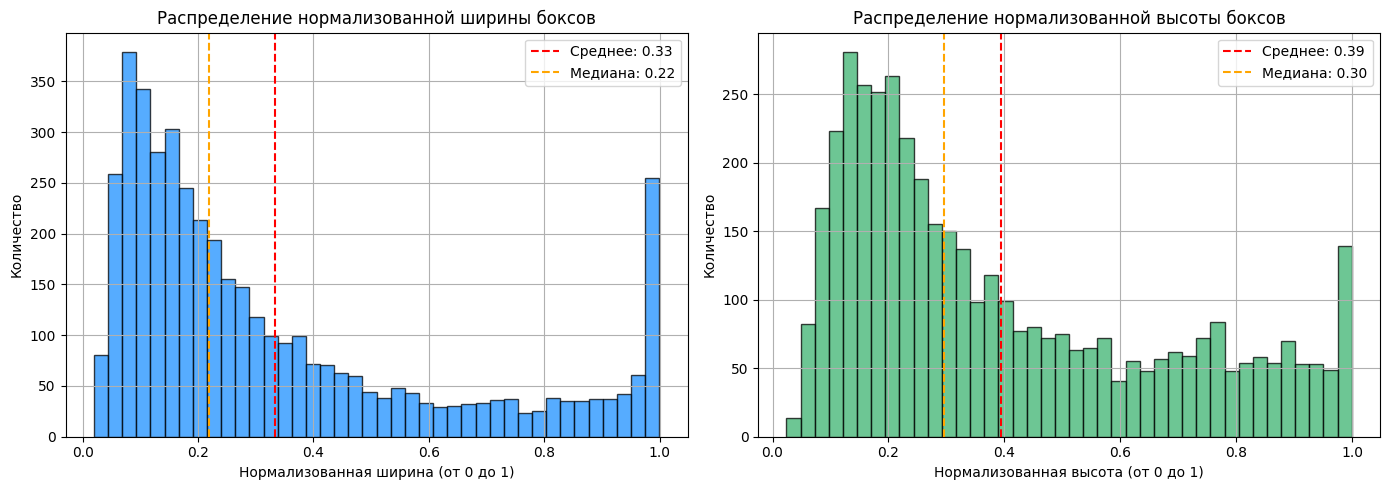

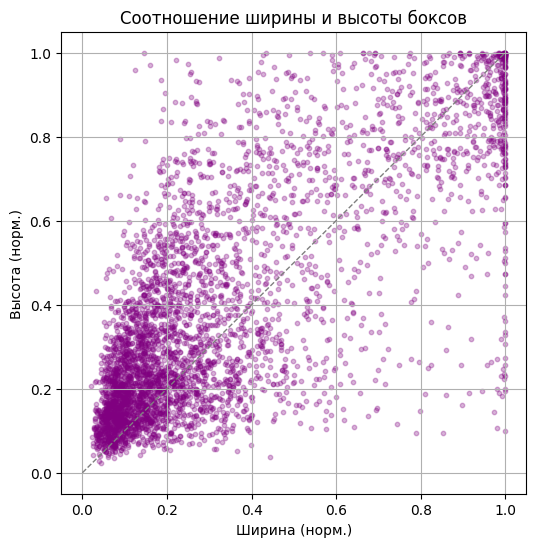

In [ ]:
# списки для хранения ширины и высоты всех bounding boxes
widths = []
heights = []

# проходим по всем файлам разметки в train-части датасета
for filename in os.listdir(train_bloom_labels):
    if not filename.endswith(".txt"):
        continue
    # полный путь к файлу разметки
    path = os.path.join(train_bloom_labels, filename)
     # открываем файл
    with open(path, "r") as f:
        lines = f.readlines()
    # каждая строка = один объект (bounding box)
    for line in lines:
        # YOLO формат:
        # class x_center y_center width height
        cls, x_center, y_center, w, h = map(float, line.split())
        # сохраняем только размеры бокса (нас не интересует позиция)
        widths.append(w)
        heights.append(h)

print(f"Всего боксов в train: {len(widths)}")

# Преобразование в numpy для статистики
widths = np.array(widths)
heights = np.array(heights)

# Гистограммы 
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=40, color='dodgerblue', alpha=0.75, edgecolor='black')
plt.axvline(np.mean(widths), color='red', linestyle='--', label=f"Среднее: {np.mean(widths):.2f}")
plt.axvline(np.median(widths), color='orange', linestyle='--', label=f"Медиана: {np.median(widths):.2f}")
plt.title("Распределение нормализованной ширины боксов")
plt.xlabel("Нормализованная ширина (от 0 до 1)")
plt.ylabel("Количество")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(heights, bins=40, color='mediumseagreen', alpha=0.75, edgecolor='black')
plt.axvline(np.mean(heights), color='red', linestyle='--', label=f"Среднее: {np.mean(heights):.2f}")
plt.axvline(np.median(heights), color='orange', linestyle='--', label=f"Медиана: {np.median(heights):.2f}")
plt.title("Распределение нормализованной высоты боксов")
plt.xlabel("Нормализованная высота (от 0 до 1)")
plt.ylabel("Количество")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Точечный график 
plt.figure(figsize=(6, 6))
plt.scatter(widths, heights, alpha=0.3, s=10, color='purple')
plt.title("Соотношение ширины и высоты боксов")
plt.xlabel("Ширина (норм.)")
plt.ylabel("Высота (норм.)")
plt.grid(True)

# Добавим линию x = y для ориентира
max_val = max(np.max(widths), np.max(heights))
plt.plot([0, max_val], [0, max_val], color='gray', linestyle='--', linewidth=1)

plt.show()

То, что среднее больше медианы, говорит о правосторонней асимметрии распределения. Иными словами:

большинство объектов имеют небольшие или средние размеры;
присутствует заметное количество очень крупных объектов, которые смещают среднее значение вправо.

Это типичная ситуация для задач детекции растений:

часть изображений содержит отдельные растения крупным планом;
часть — группы растений или растения на большом расстоянии.


На обеих гистограммах хорошо заметен пик около значения 1.0.

Это означает, что в датасете присутствует значительное число боксов, занимающих практически всё изображение.

Это повышает разнообразие масштабов объектов и способствует более устойчивому обучению модели? 

Из графиков видно, что ширина и высота объектов изменяются практически по всему диапазону

Это очень хороший признак для YOLO.




Положительная корреляция:

Чем шире объект, тем выше он становится.

Точки образуют диагональное облако.

Это говорит о том, что большинство объектов сохраняют примерно одинаковые пропорции.

Анализ 4262 размеченных объектов показал высокую вариативность размеров bounding boxes. Большинство объектов имеют небольшие и средние размеры, однако в выборке также присутствует значительное количество крупных объектов, занимающих большую часть изображения. Наблюдается положительная корреляция между шириной и высотой объектов, что свидетельствует о согласованности разметки и отсутствии значительного числа аномальных ограничивающих прямоугольников.